In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


In [2]:
transform=transforms.Compose([
    transforms.Resize((224,224)),    
    transforms.ToTensor() 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.5*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

15000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0 = torch.load(f'model_{model_algo}_0_14.pth')

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.3174572314898172,train_accu=0.5623333333333334
Epoch=0,valid_loss=1.3305241205215455,valid_accu=0.5542
0
Epoch=1,train_loss=1.177010033162435,train_accu=0.6048666666666667
Epoch=1,valid_loss=1.1976277265548707,valid_accu=0.5929
0
Epoch=2,train_loss=1.1005985081354777,train_accu=0.628
Epoch=2,valid_loss=1.1247666207313538,valid_accu=0.6183
0
Epoch=3,train_loss=1.0543338073730468,train_accu=0.6454666666666666
Epoch=3,valid_loss=1.0822834016799927,valid_accu=0.6347
0
Epoch=4,train_loss=1.030868149916331,train_accu=0.6466666666666666
Epoch=4,valid_loss=1.0648322200775147,valid_accu=0.6367
0
Epoch=5,train_loss=1.0006859223047893,train_accu=0.6595333333333333
Epoch=5,valid_loss=1.0384942005157471,valid_accu=0.6443
0
Epoch=6,train_loss=0.9731033491452535,train_accu=0.6742
Epoch=6,valid_loss=1.0128631711006164,valid_accu=0.6579
0
Epoch=7,train_loss=0.9630863679567973,train_accu=0.6734
Epoch=7,valid_loss=1.0084354560852051,valid_accu=0.6537
Epoch=8,train_loss=0.945491009871

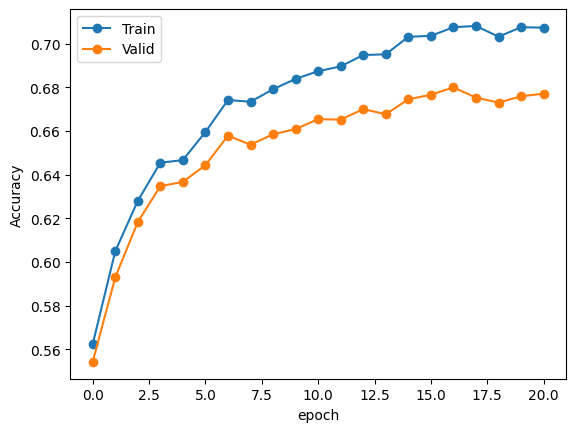

In [11]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_11.pth')

In [12]:
model_0

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [13]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.8704880096117655, 0.7075333333333333)

In [14]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.9386452447891236, 0.68)

In [15]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

airplane      0.718473
automobile    0.743520
bird          0.512325
cat           0.485244
deer          0.749370
dog           0.673971
frog          0.787736
horse         0.719836
ship          0.834532
truck         0.838436
dtype: float64

In [16]:
targetF=[x  for x in each_accu.nsmallest(2).index.map(trainset.dataset.classess)]
targetF

[3, 2]

In [17]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('loss',0.9)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(5610, 9390)

In [18]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(4039, 5961)

In [19]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [20]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [21]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.6330712836265564,train_accu=0.6310666666666667
Epoch=0,valid_loss=0.6507272037506103,valid_accu=0.5966
0
Epoch=1,train_loss=0.6222662117004395,train_accu=0.6491333333333333
Epoch=1,valid_loss=0.6393591597557068,valid_accu=0.6158
0
Epoch=2,train_loss=0.6168259903271993,train_accu=0.657
Epoch=2,valid_loss=0.6333327397346497,valid_accu=0.6265
0
Epoch=3,train_loss=0.6122284625053406,train_accu=0.6620666666666667
Epoch=3,valid_loss=0.6284262153625488,valid_accu=0.6368
0
Epoch=4,train_loss=0.6086161738395691,train_accu=0.6681333333333334
Epoch=4,valid_loss=0.6246655887603759,valid_accu=0.6443
0
Epoch=5,train_loss=0.6079185135523478,train_accu=0.6691333333333334
Epoch=5,valid_loss=0.6225011004447937,valid_accu=0.6497
0
Epoch=6,train_loss=0.6050568604151408,train_accu=0.6727333333333333
Epoch=6,valid_loss=0.6196473373413086,valid_accu=0.654
0
Epoch=7,train_loss=0.6028357490857442,train_accu=0.6752666666666667
Epoch=7,valid_loss=0.6175541059494019,valid_accu=0.6556
0
Epoch=

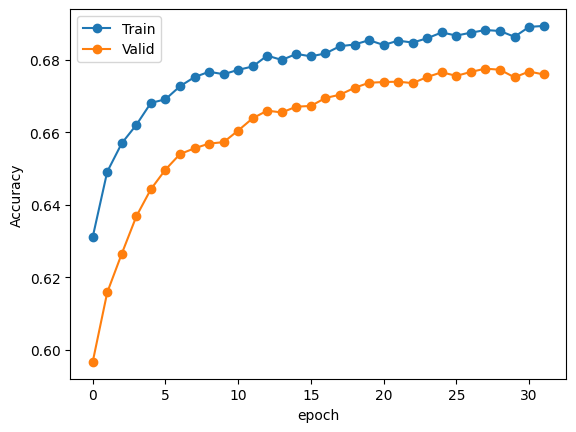

In [22]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.9043737398041958,train_accu=0.7681576144834931
Epoch=0,valid_loss=0.8897248178275514,valid_accu=0.762791477939943
0
Epoch=1,train_loss=0.6753454085229177,train_accu=0.8129925452609159
Epoch=1,valid_loss=0.6619786027393332,valid_accu=0.81311860426103
0
Epoch=2,train_loss=0.5577493271380821,train_accu=0.8499467518636847
Epoch=2,valid_loss=0.5445342954923754,valid_accu=0.8506961919141084
0
Epoch=3,train_loss=0.4898227180916661,train_accu=0.8627263045793397
Epoch=3,valid_loss=0.4798556824015243,valid_accu=0.8683106861264889
0
Epoch=4,train_loss=0.4443646942083828,train_accu=0.8749733759318424
Epoch=4,valid_loss=0.43513238562011336,valid_accu=0.8780405972152323
0
Epoch=5,train_loss=0.40155771004633145,train_accu=0.889776357827476
Epoch=5,valid_loss=0.39336506093714263,valid_accu=0.8928032209360846
0
Epoch=6,train_loss=0.37312259127855046,train_accu=0.8985090521831736
Epoch=6,valid_loss=0.36764160385569394,valid_accu=0.9033719174635129
0
Epoch=7,train_loss=0.348571669027

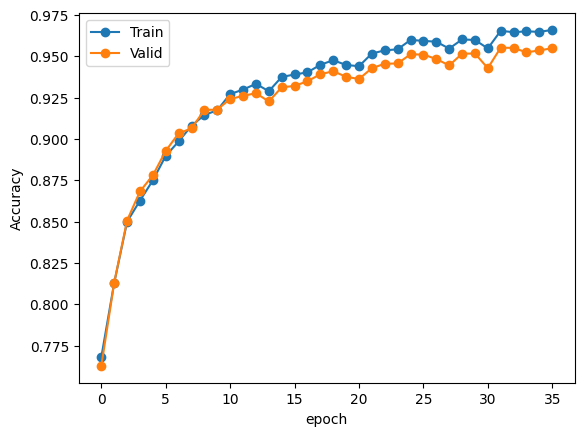

In [23]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [24]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=2.0006334503704215,train_accu=0.279144385026738
Epoch=0,valid_loss=1.9975304579374724,valid_accu=0.28893290418420403
0
Epoch=1,train_loss=1.9021041612574123,train_accu=0.3048128342245989
Epoch=1,valid_loss=1.9035624087698007,valid_accu=0.3057687546422382
0
Epoch=2,train_loss=1.844244152169389,train_accu=0.3249554367201426
Epoch=2,valid_loss=1.8569302517873694,valid_accu=0.31245357761822234
0
Epoch=3,train_loss=1.8058990393942902,train_accu=0.33493761140819966
Epoch=3,valid_loss=1.8267504461155755,valid_accu=0.3253280514978955
0
Epoch=4,train_loss=1.780861528417006,train_accu=0.34705882352941175
Epoch=4,valid_loss=1.8057015427978773,valid_accu=0.33151770240158457
0
Epoch=5,train_loss=1.75216473049871,train_accu=0.3499108734402852
Epoch=5,valid_loss=1.7858542177340098,valid_accu=0.33547907897994556
0
Epoch=6,train_loss=1.7292383250918193,train_accu=0.36345811051693405
Epoch=6,valid_loss=1.7678321329311852,valid_accu=0.34686803664273336
0
Epoch=7,train_loss=1.7131949044

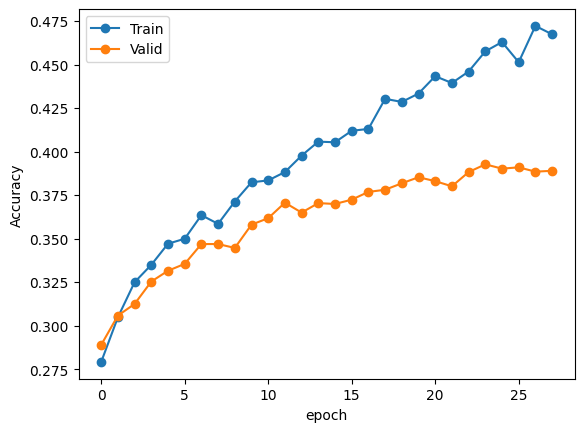

In [25]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [26]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.5839617705027262, 0.6882666666666667)

In [27]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.599264677143097, 0.6776)

In [28]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.16554710759649388, 0.9653887113951012)

In [29]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(1.5336561349198992, 0.4575757575757576)

In [30]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.18411358743981016, 0.9552088575742325)

In [31]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.6475312284208459, 0.39267145333003217)

In [32]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.6772201449553171, 0.7754666666666666, 5610)

In [33]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.775187866973877, 0.728, 4039)

In [34]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)

            softmax=torch.softmax(out_growth, dim=1)

            out=model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)


            for pred,d,t in zip(y_pred_tag,data,target):

                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    sum_F+=1
                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [35]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(1.1273971492767334, 0.6337333333333334, 6468, 8532)

In [36]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.1879717485427856, 0.6111, 4339, 5661)

In [37]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [38]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.870488,0.707533,0.938645,0.680000
1,Model_Decision,0.583962,0.688267,0.583962,0.677600
2,Model_T,0.165547,0.965389,0.184114,0.955209
3,Model_F,1.533656,0.457576,1.647531,0.392671
4,Total_Model,1.127397,0.633733,1.187972,0.611100
5,Total_Model_without_decision,0.677220,0.775467,0.775188,0.728000


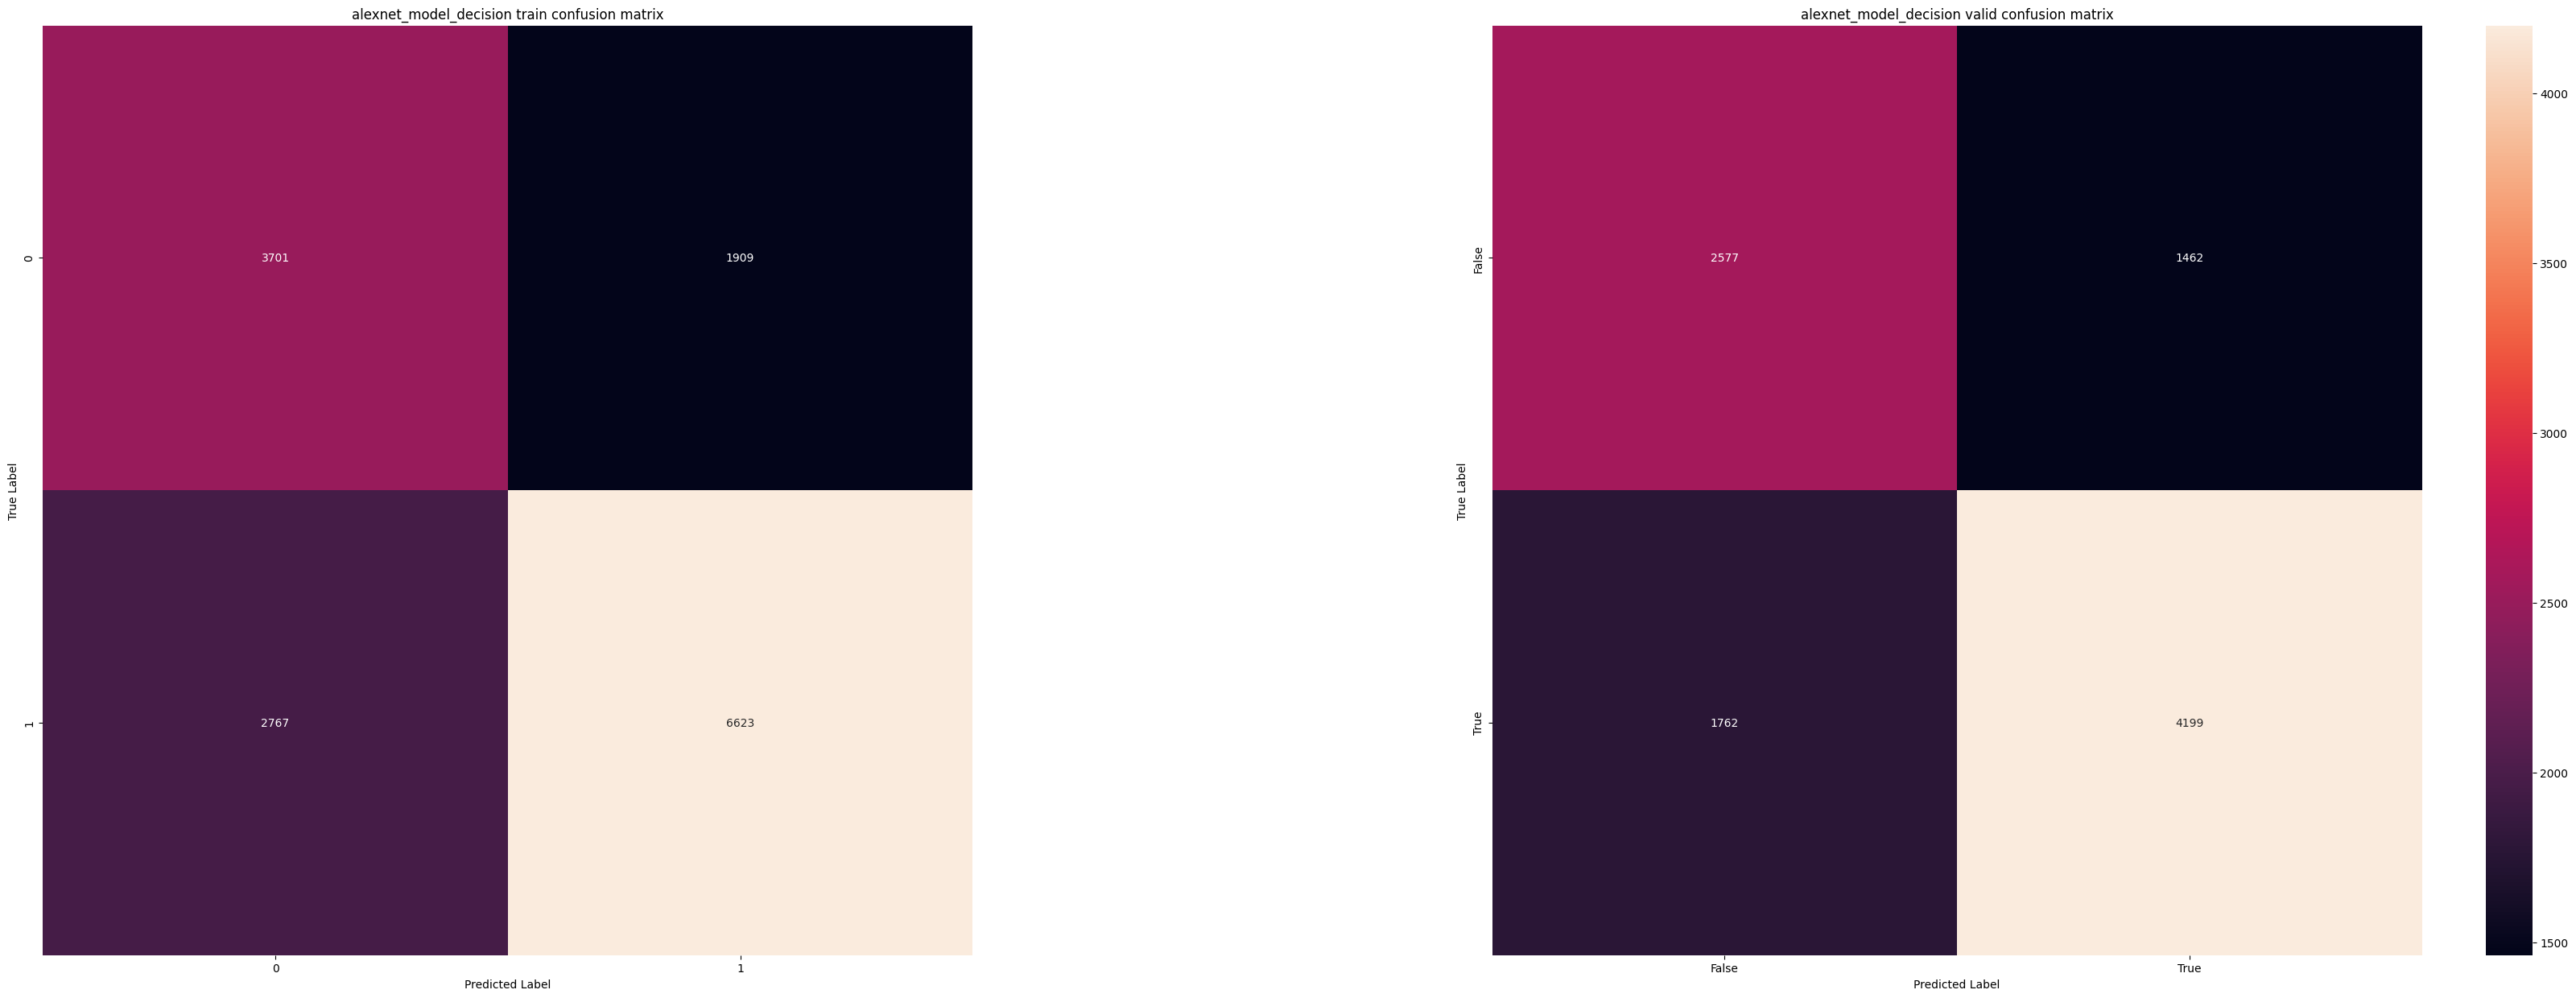

In [39]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

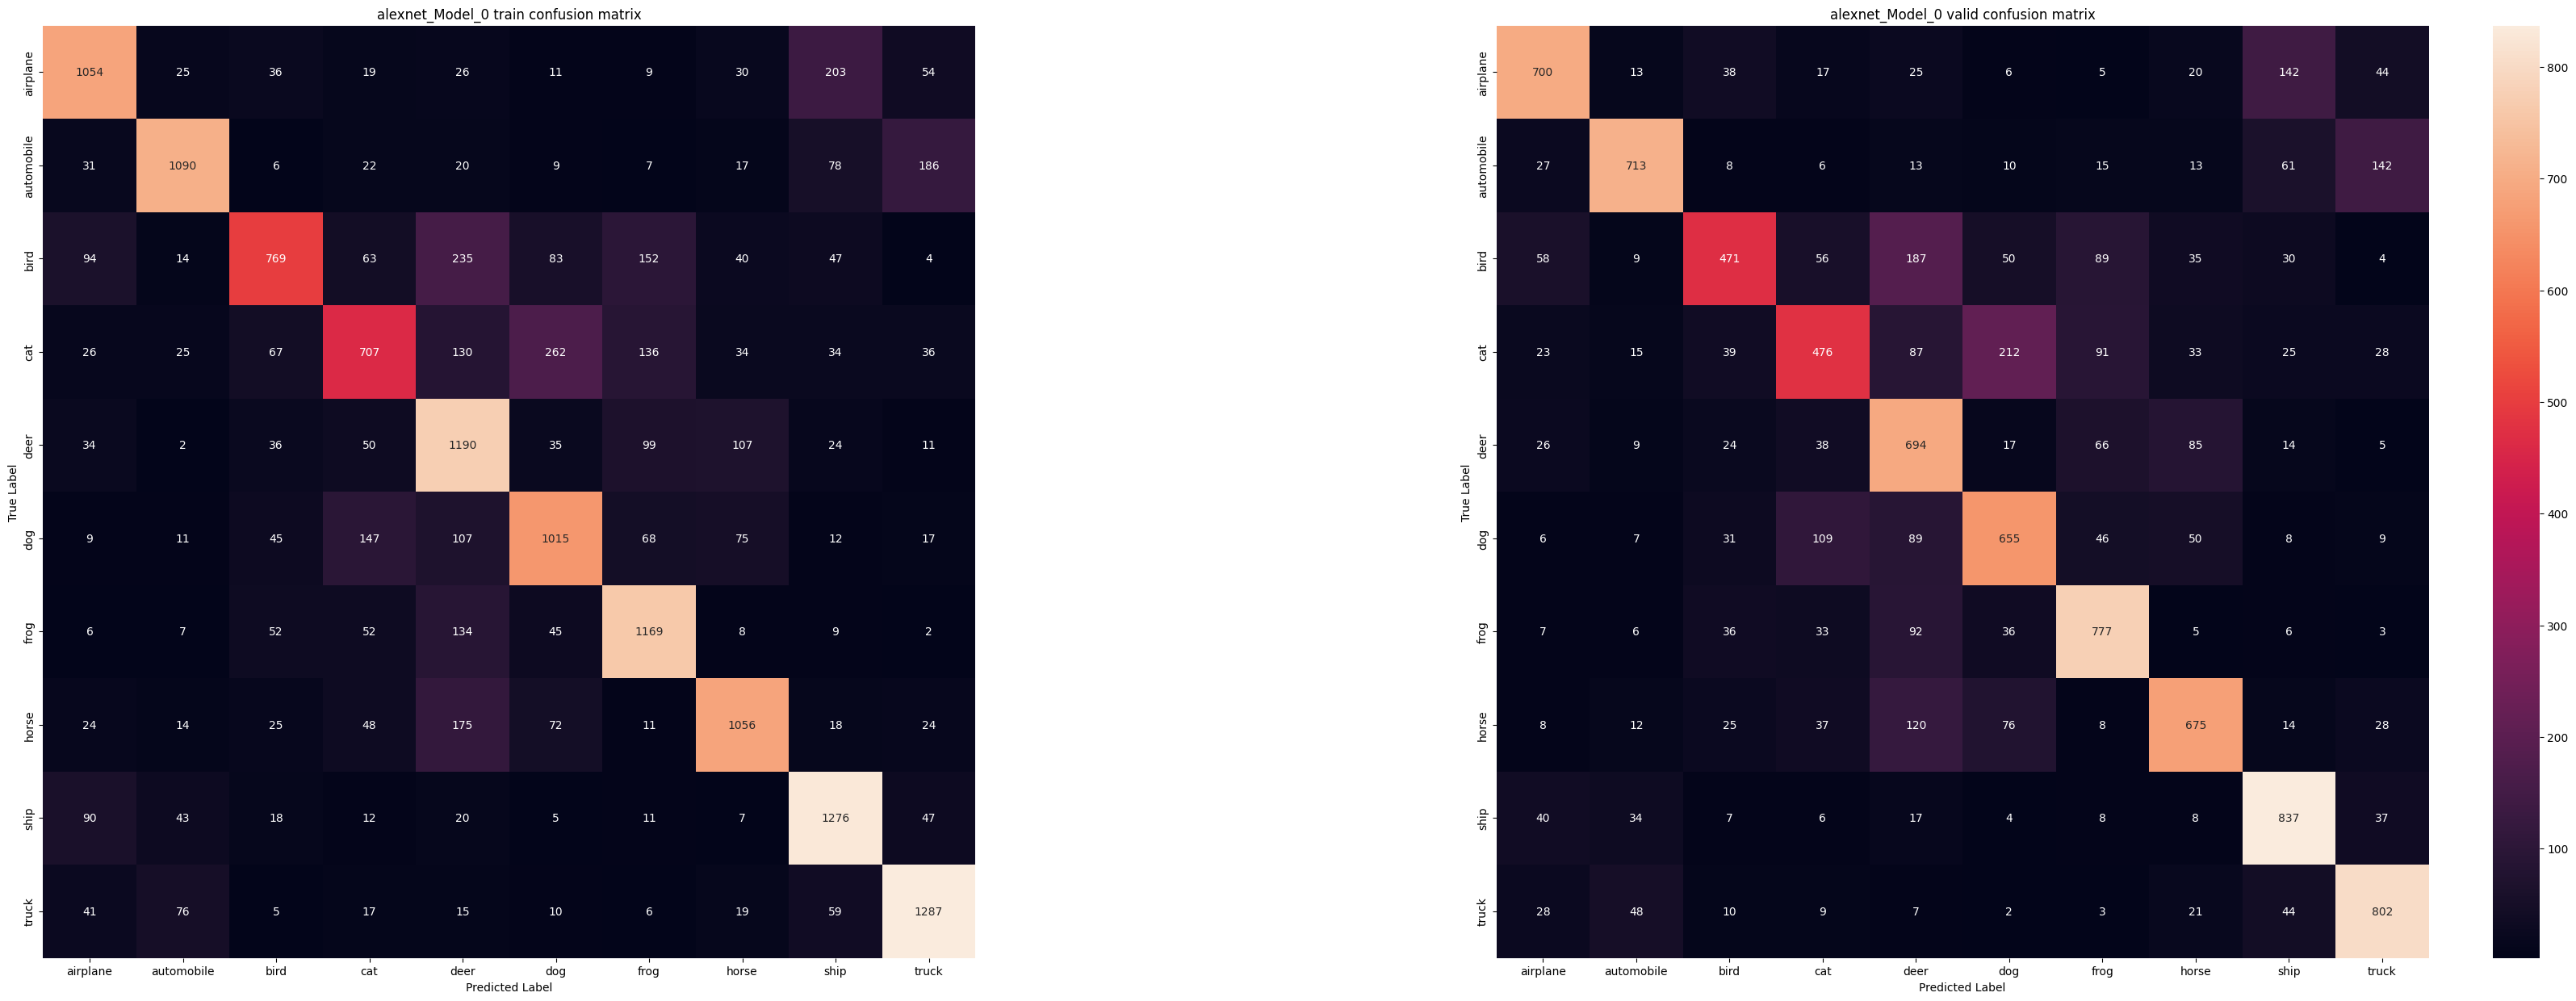

In [40]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

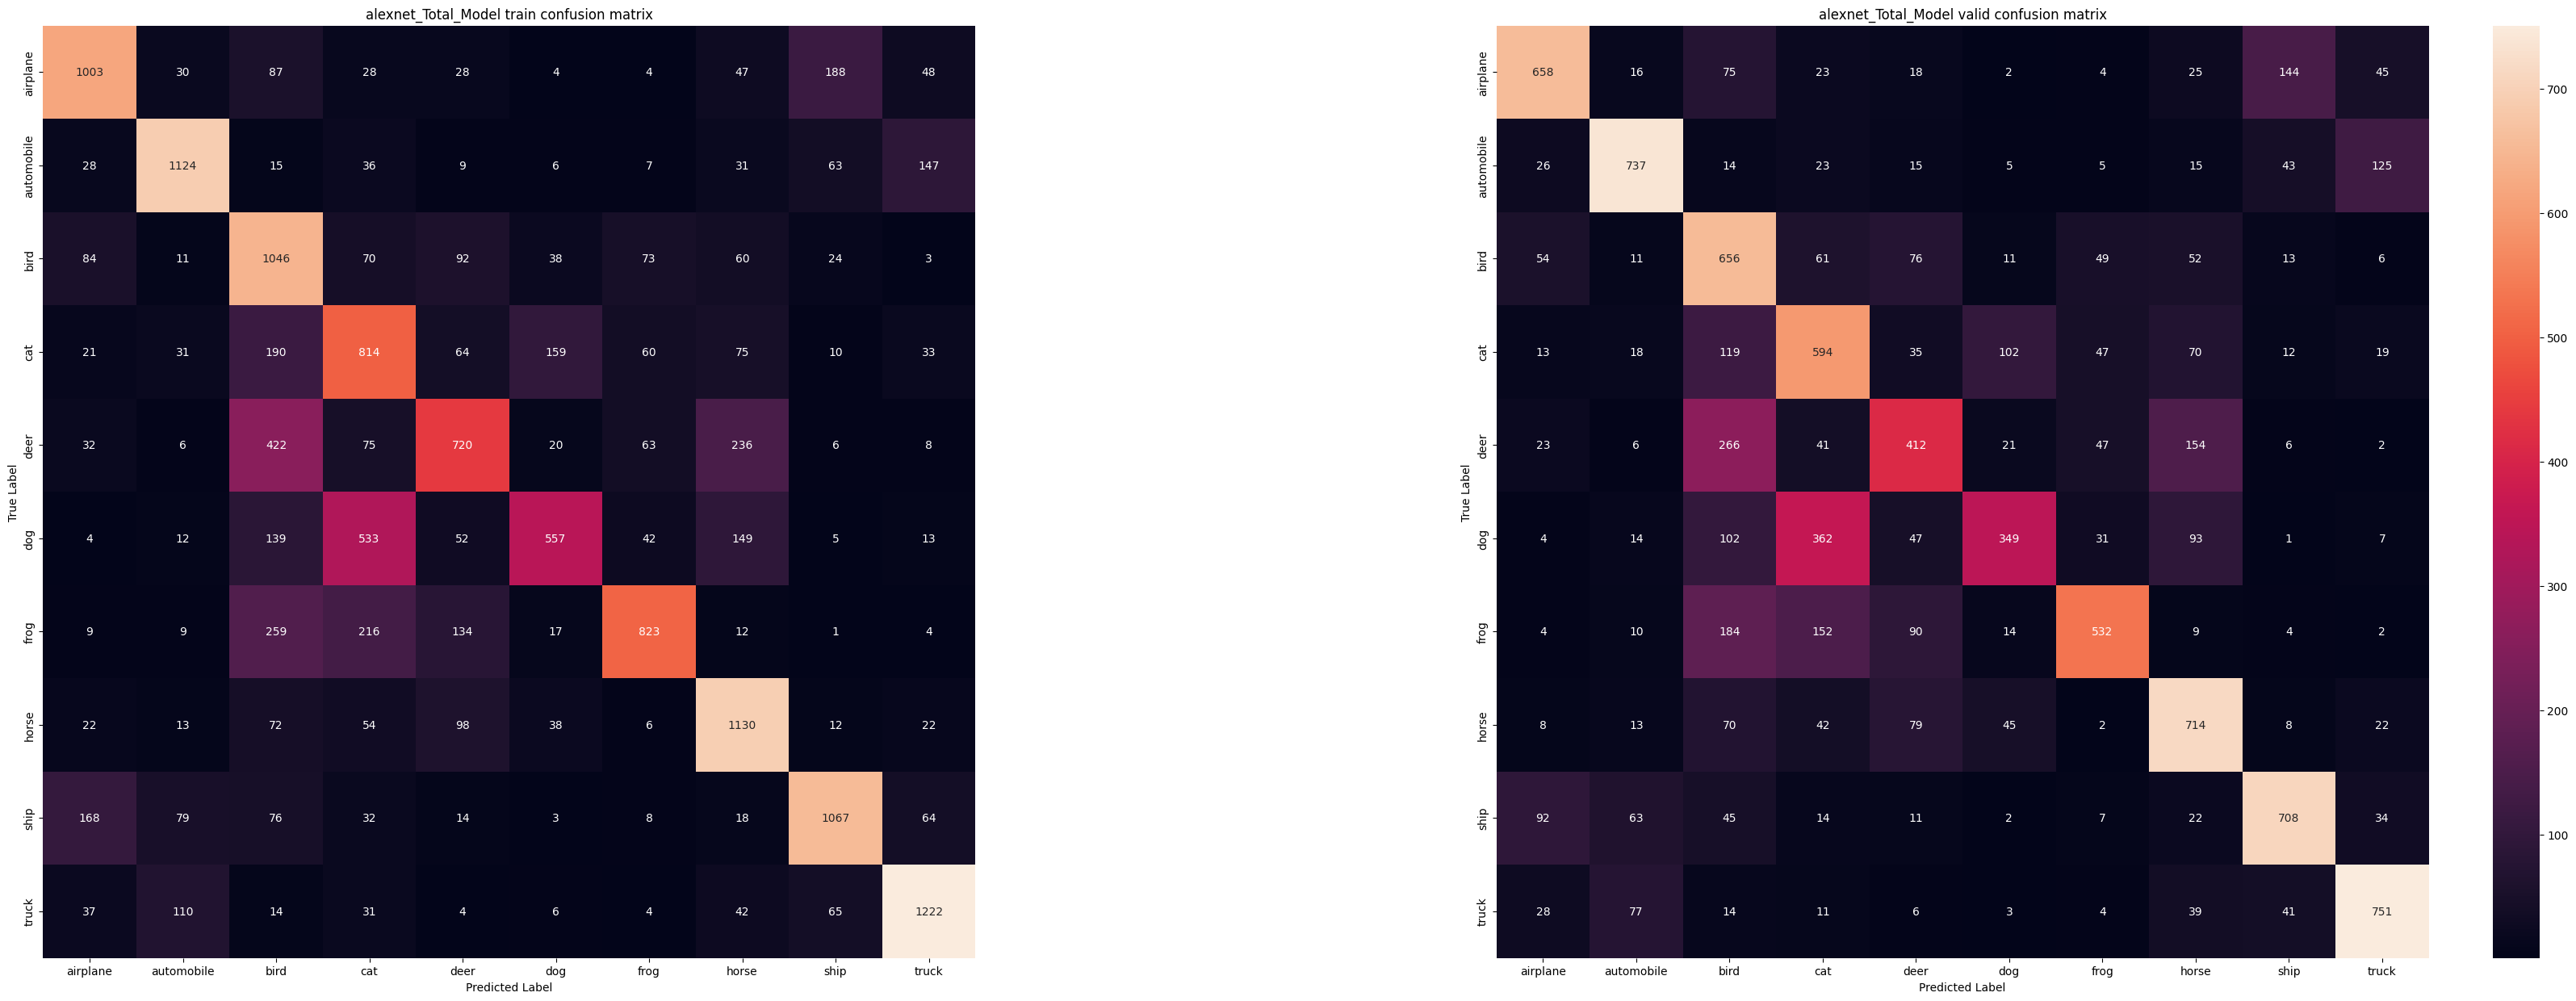

In [41]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

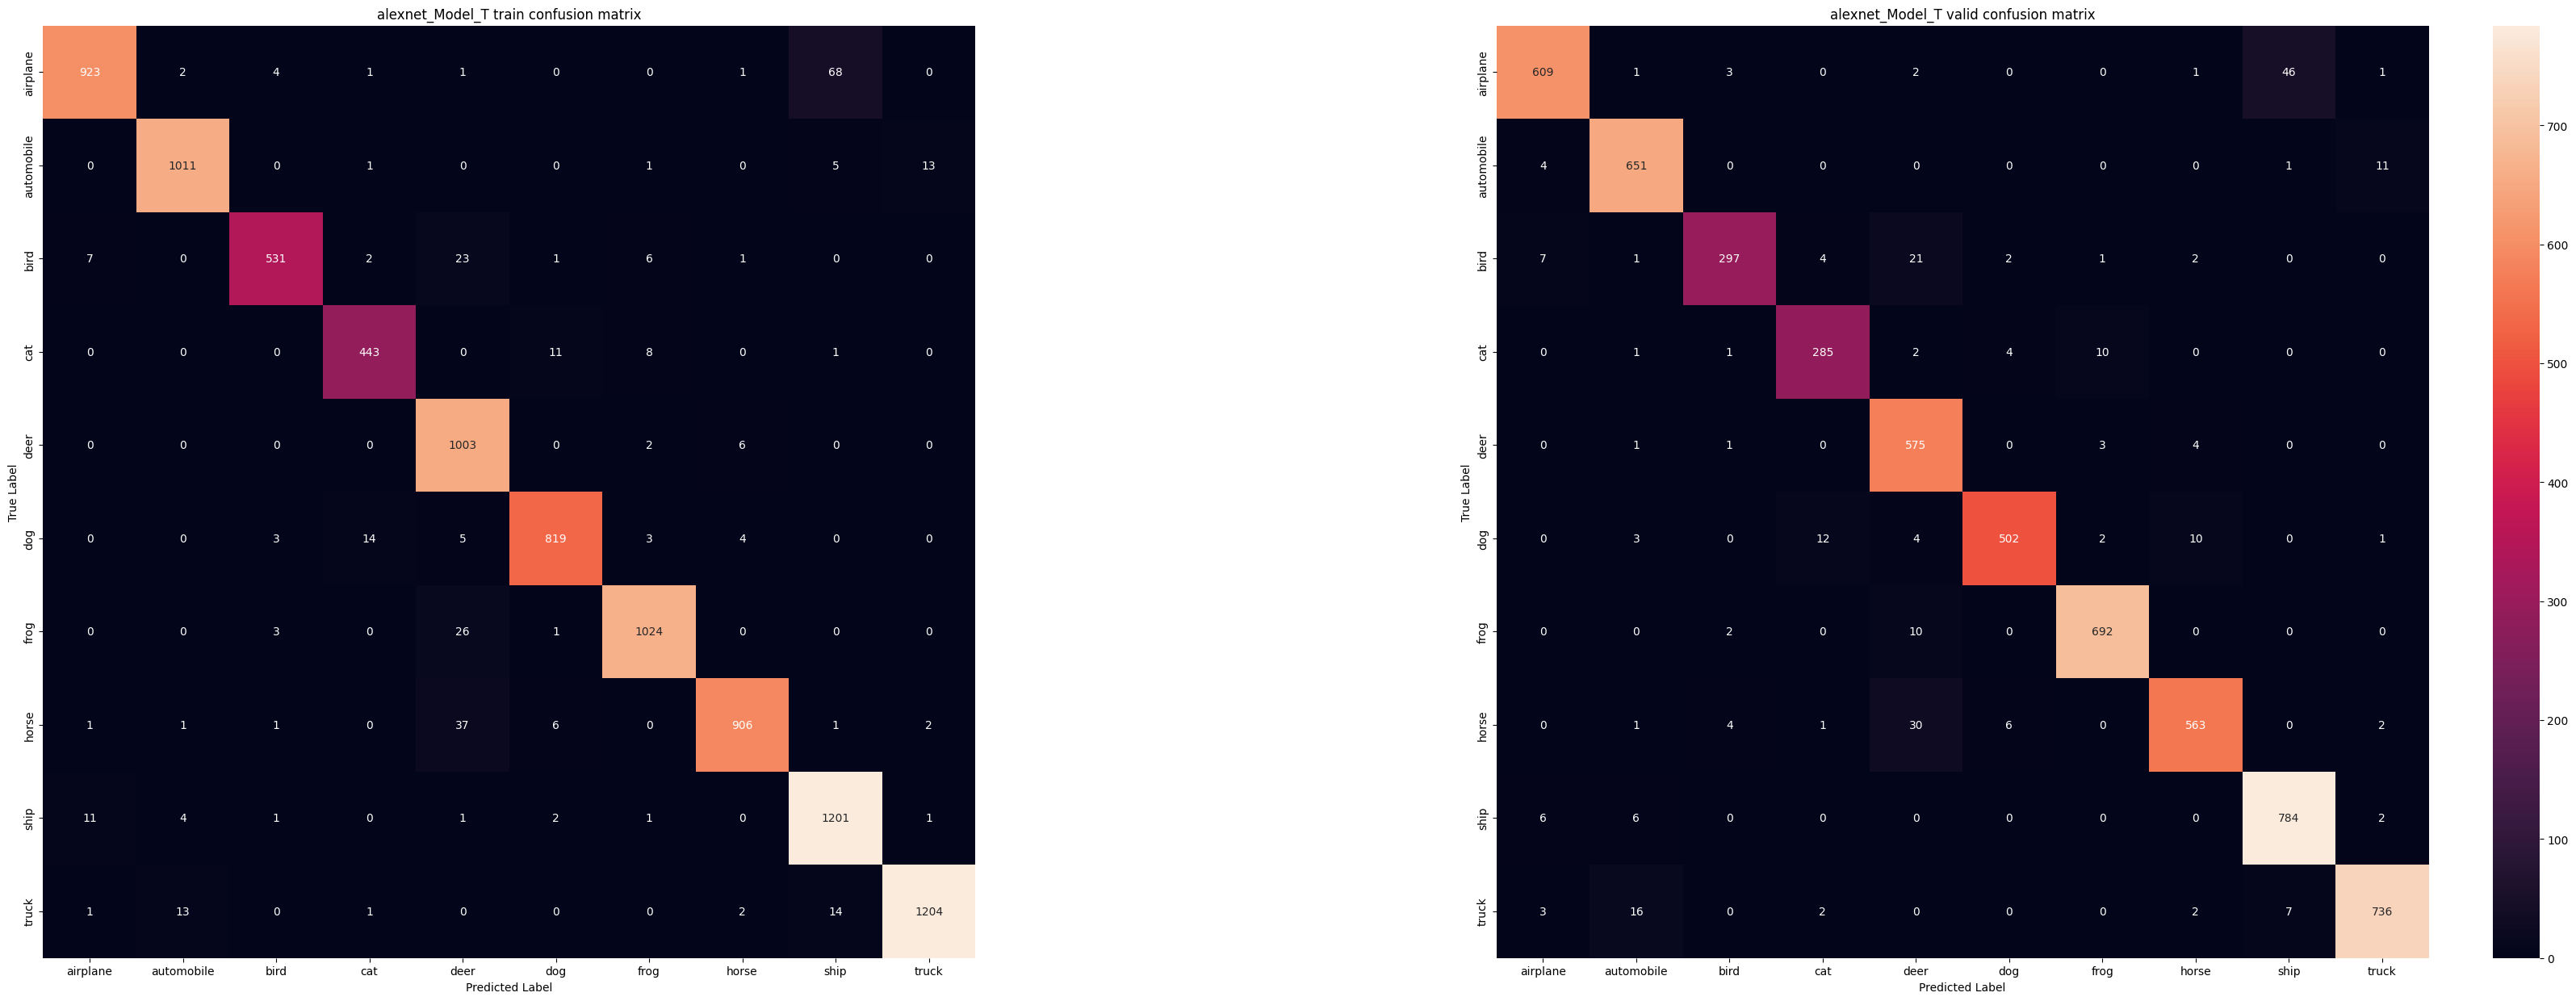

In [42]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

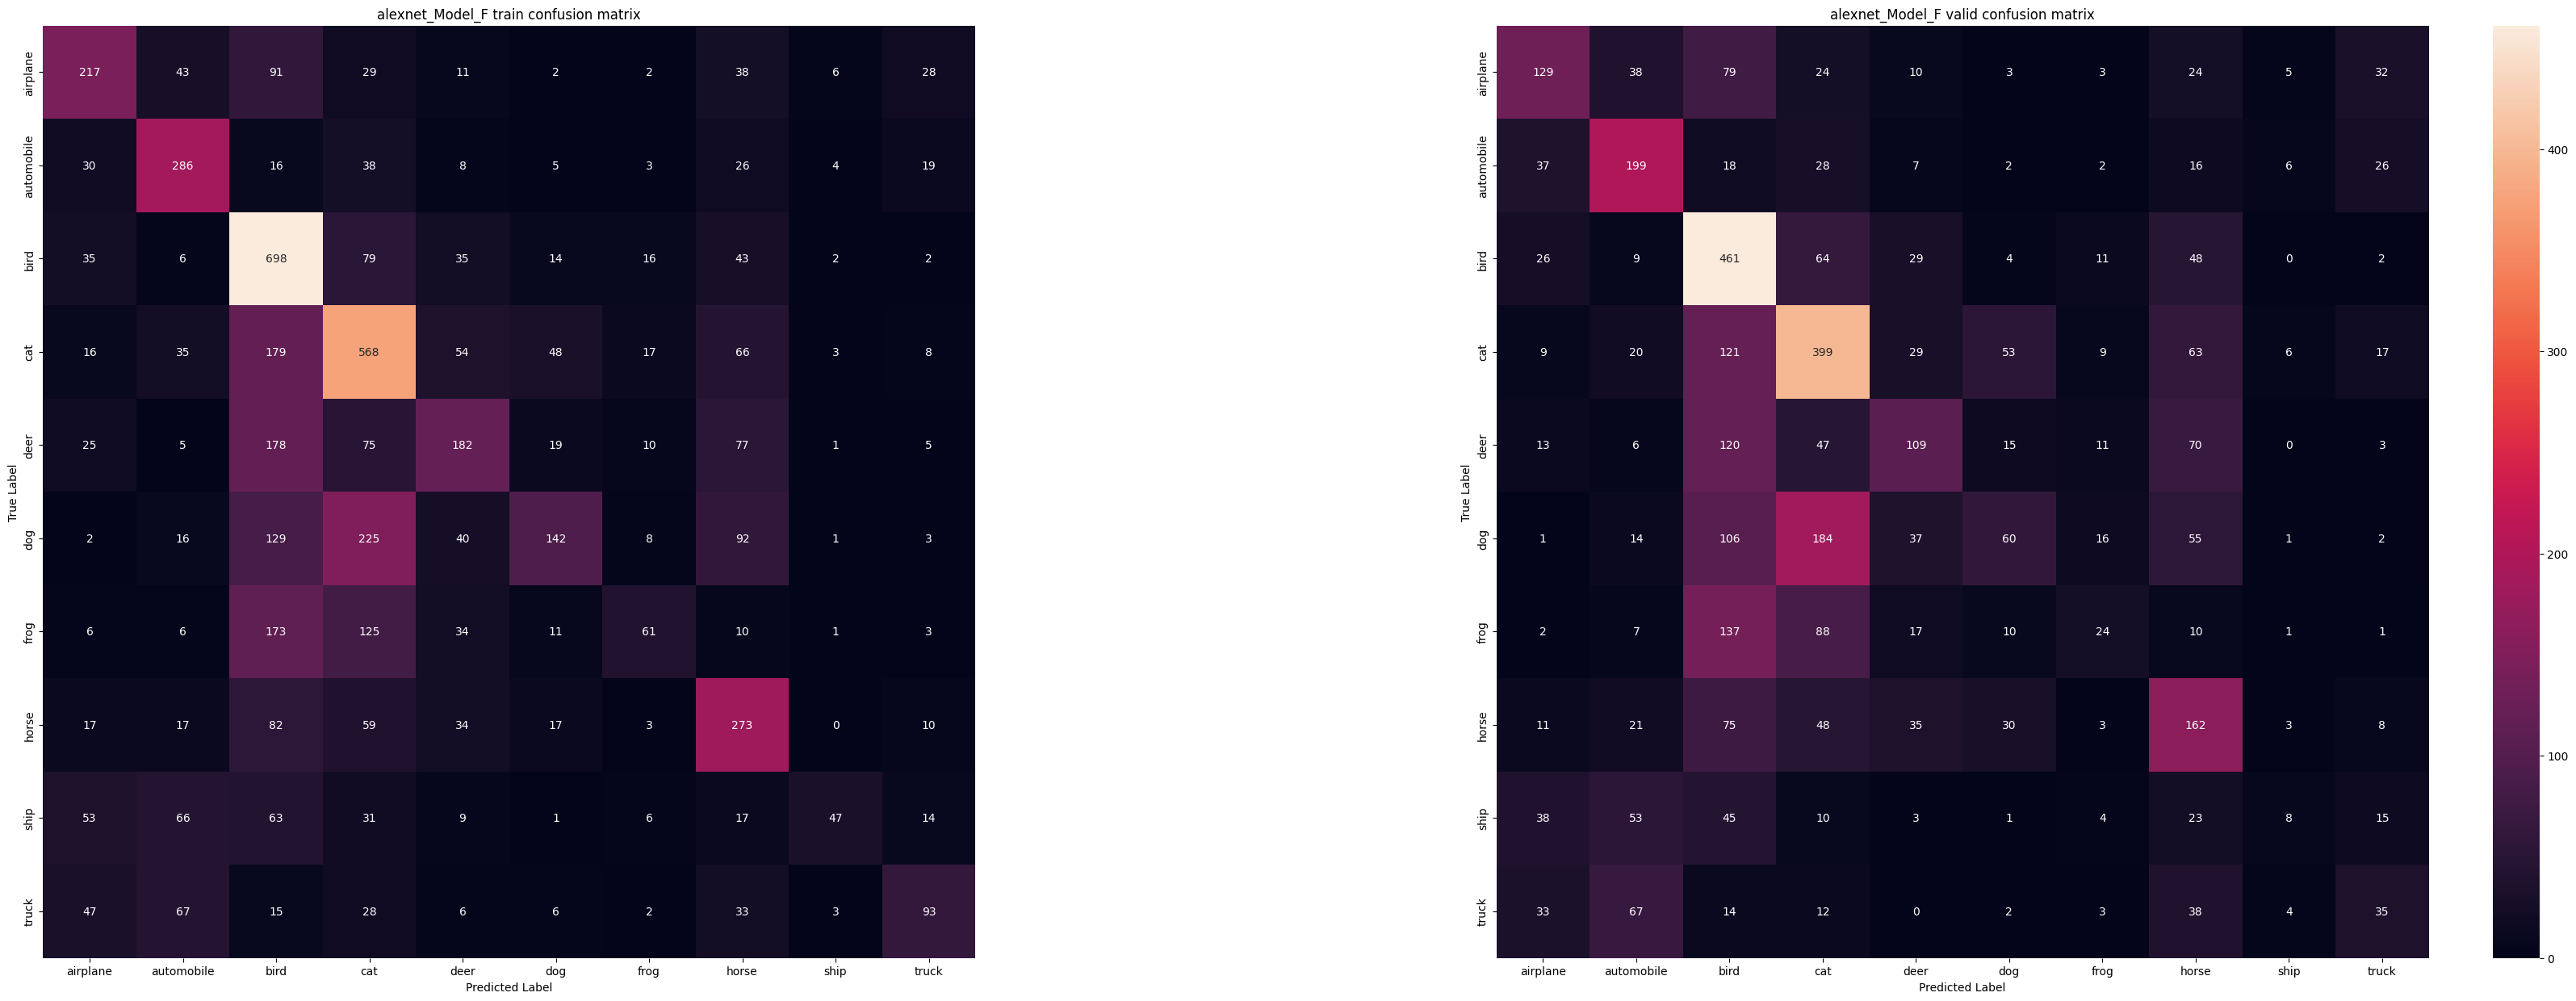

In [43]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [44]:
#全部模型裝在一起的表現
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()
                pred_T=torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                
                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item()
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [45]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Match_F,Match_T,Match_0
0,19977,2,2,2,2,True,True,True
1,8918,3,3,8,3,True,False,True
2,24790,4,4,4,4,True,True,True
3,34680,4,4,4,4,True,True,True
4,30250,4,2,4,4,False,True,True
...,...,...,...,...,...,...,...,...
14995,42258,3,2,8,8,False,False,False
14996,49471,2,2,2,2,True,True,True
14997,24683,9,9,9,9,True,True,True
14998,34982,1,1,1,1,True,True,True
